**Transaction Amount Analysis**

Importing necessary libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import plotly.express as px

load datasets

In [3]:
df1 = pd.read_csv('cleaned_data.csv')

df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Transaction Time Behavior Analysis

Time-based behavior helps detect fraud when transactions happen too quickly/at unusual times.

Step 1: Convert Time to Hours

This makes analysis easier.

In [4]:
df1["Hour"] = (df1["Time"] / 3600) % 24

print(df1[["Time", "Hour"]].head())

   Time      Hour
0   0.0  0.000000
1   0.0  0.000000
2   1.0  0.000278
3   1.0  0.000278
4   2.0  0.000556


Step 2: Transactions Per Hour (lim=20)

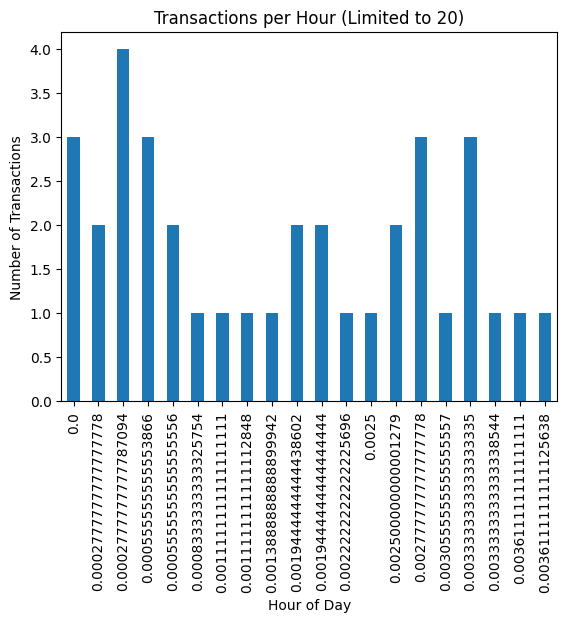

In [5]:
hourly_tx = df1.groupby("Hour").size().head(20)  # limit to 20 entries

hourly_tx.plot(kind="bar")
plt.title("Transactions per Hour (Limited to 20)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

Step 3 — Fraud Occurrence by Hour (lim=20)

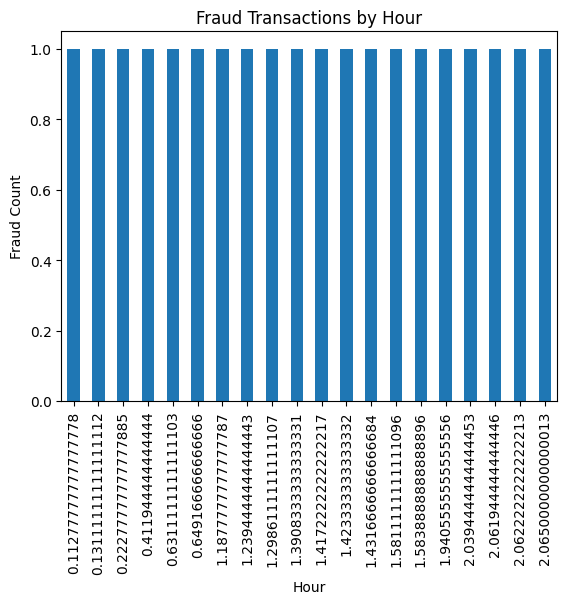

In [7]:
fraud_hourly = df1[df1["Class"] == 1].groupby("Hour").size().head(20)  # limit to 20 entries

fraud_hourly.plot(kind="bar")
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")
plt.show()

End